# Notebook 0: Model Instrumentation

**Goal:** Build the infrastructure to load Llama 3 8B with MLX, intercept intermediate hidden states, extract attention weight matrices, and apply the Logit Lens to arbitrary layers. This infrastructure will be reused across all future experiments.


In [1]:
import mlx.core as mx
import mlx.nn as nn
from mlx_lm import load, generate
import inspect
import matplotlib.pyplot as plt
import numpy as np

## 1. Load the Model
We use the 8B parameter variant of Llama 3 (4-bit quantized). It runs efficiently on M-series Macs.

In [2]:
model_id = "mlx-community/Meta-Llama-3-8B-Instruct-4bit"
print(f"Loading {model_id}...")
model, tokenizer = load(model_id)

Loading mlx-community/Meta-Llama-3-8B-Instruct-4bit...


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

## 2. Implement Hidden State Extraction
Because MLX does not support `output_hidden_states=True` by default out of the box for all models, we can manually implement a forward pass that extracts the activations after each Transformer block.

In [3]:
def extract_hidden_states(model, prompt):
    """
    Tokenizes a prompt and runs a manual forward pass to extract hidden states at each layer.
    """
    tokens = mx.array([tokenizer.encode(prompt)])
    
    # 1. Initial Embedding
    h = model.model.embed_tokens(tokens)
    
    hidden_states = {} # Dictionary to store intermediate states
    
    # 2. Iterate through layers
    for i, layer in enumerate(model.model.layers):
        # Pass through transformer block
        # MLX requires the causal mask to accurately match model outputs for sequences > 1
        from mlx_lm.models.llama import create_attention_mask
        mask = create_attention_mask(h, None)
        h = layer(h, mask, None)
        hidden_states[i] = h
        
    return tokens, hidden_states

# Let's test it
prompt = "The capital of France is"
tokens, hidden_states = extract_hidden_states(model, prompt)

print(f"Prompt: '{prompt}'")
print(f"Tokens: {tokens.tolist()[0]}")
print(f"Number of layers captured: {len(hidden_states)}")
print(f"Shape of final hidden state: {hidden_states[len(hidden_states)-1].shape}")

Prompt: 'The capital of France is'
Tokens: [791, 6864, 315, 9822, 374]
Number of layers captured: 32
Shape of final hidden state: (1, 5, 4096)


## 3. Implement The Logit Lens
Now that we have hidden states (which are vectors of size `4096` for Llama 3 8B), we need a way to see what the model “thinks” at that layer. We do this by applying the final LayerNorm and multiplying by the unembedding matrix.

In [4]:
def apply_logit_lens(hidden_state, model):
    """
    Applies the final LayerNorm and unembedding matrix to an intermediate hidden state.
    """
    # Apply final layernorm
    h_normed = model.model.norm(hidden_state)
    
    # Undo embedding (lm_head differs by model architecture)
    if hasattr(model, 'lm_head'):
        logits = model.lm_head(h_normed)
    elif hasattr(model.model, 'embed_tokens'):
        # Llama tied embeddings fallback
        if hasattr(model.model.embed_tokens, 'as_linear'):
            logits = model.model.embed_tokens.as_linear(h_normed)
        else:
            logits = h_normed @ model.model.embed_tokens.weight.T
    else:
        raise ValueError("Cannot find unembedding layer")
        
    return logits

def top_k_tokens(logits, tokenizer, k=10):
    """
    Decodes the top-k tokens from the logits of the final sequence position.
    """
    # Get last token logits for the batch: shape (batch, seq_len, vocab_size) -> (vocab_size,)
    last_logits = logits[0, -1, :]
    
    # Get top k indices
    top_indices = mx.argpartition(-last_logits, kth=k)[:k]
    top_values = last_logits[top_indices]
    
    # Sort them
    sort_idx = mx.argsort(-top_values)
    top_indices = top_indices[sort_idx]
    top_values = top_values[sort_idx]
    
    # Calculate pseudo-probabilities
    top_probs = mx.softmax(top_values).tolist() 
    top_indices = top_indices.tolist()

    results = []
    for idx, prob in zip(top_indices, top_probs):
        token_str = tokenizer.decode([idx])
        results.append((token_str, prob))
        
    return results

### Testing the Setup
Let's make sure our manual extraction matches the standard `model(tokens)` output.

In [5]:
# Ground truth with standard MLX forward pass
print("[Ground Truth Output]")
normal_logits = model(tokens)
for token, prob in top_k_tokens(normal_logits, tokenizer, k=5):
    print(f"{repr(token):<12} | Score: {prob:.4f}")

print("\n[Manual Logit Lens on Final Layer]")
final_layer_idx = len(model.model.layers) - 1
lens_logits = apply_logit_lens(hidden_states[final_layer_idx], model)
for token, prob in top_k_tokens(lens_logits, tokenizer, k=5):
    print(f"{repr(token):<12} | Score: {prob:.4f}")
    
diff = mx.abs(normal_logits - lens_logits).max().item()
print(f"\nMax discrepancy: {diff:.6f}")

[Ground Truth Output]
' Paris'     | Score: 0.9243
' the'       | Score: 0.0209
' called'    | Score: 0.0206
' **'        | Score: 0.0183
' not'       | Score: 0.0161

[Manual Logit Lens on Final Layer]
' Paris'     | Score: 0.9243
' the'       | Score: 0.0209
' called'    | Score: 0.0206
' **'        | Score: 0.0183
' not'       | Score: 0.0161

Max discrepancy: 0.000000


## 4. Extracting Attention Patterns
To extract attention matrices, we will create a monkey-patch contextual manager. Note that MLX uses `mlx.core.fast.scaled_dot_product_attention`, so we intercept the `__call__` method of the `Attention` block itself to extract the raw matrices.

In [6]:
from mlx_lm.models.llama import Attention

class AttentionExtractor:
    def __init__(self):
        self.weights = []
        self.original_attn_call = Attention.__call__
        
    def __enter__(self):
        self.weights = []
        # We inject a function that computes the matrices identically, but captures `weights`
        def patched_attn_call(attn_self, x, mask=None, cache=None):
            B, L, D = x.shape
            queries, keys, values = attn_self.q_proj(x), attn_self.k_proj(x), attn_self.v_proj(x)
            
            queries = queries.reshape(B, L, attn_self.n_heads, -1).transpose(0, 2, 1, 3)
            keys = keys.reshape(B, L, attn_self.n_kv_heads, -1).transpose(0, 2, 1, 3)
            values = values.reshape(B, L, attn_self.n_kv_heads, -1).transpose(0, 2, 1, 3)

            if cache is not None:
                queries = attn_self.rope(queries, offset=cache.offset)
                keys = attn_self.rope(keys, offset=cache.offset)
                keys, values = cache.update_and_fetch(keys, values)
            else:
                queries = attn_self.rope(queries)
                keys = attn_self.rope(keys)

            # Perform Grouped Query Attention repeat manually
            if attn_self.n_heads != attn_self.n_kv_heads:
                repeats = attn_self.n_heads // attn_self.n_kv_heads
                k = mx.repeat(mx.expand_dims(keys, 2), repeats, axis=2).reshape(B, attn_self.n_heads, keys.shape[2], -1)
                v = mx.repeat(mx.expand_dims(values, 2), repeats, axis=2).reshape(B, attn_self.n_heads, values.shape[2], -1)
            else:
                k, v = keys, values
                
            # Core Attention Equation: softmax((Q * scale * K^T) + mask)
            scores = (queries * attn_self.scale) @ k.transpose(0, 1, 3, 2)
            
            # Handle MLX str mask ('causal') vs explicit tensor mask
            if mask is not None and isinstance(mask, mx.array):
                scores = scores + mask
            elif mask == 'causal':
                # Construct standard causal mask
                causal_mask = nn.MultiHeadAttention.create_additive_causal_mask(L, queries.dtype)
                scores = scores + causal_mask
                
            weights = mx.softmax(scores, axis=-1)
            
            # CAPTURE IT
            self.weights.append(weights)
            
            output = weights @ v
            output = output.transpose(0, 2, 1, 3).reshape(B, L, -1)
            return attn_self.o_proj(output)
            
        Attention.__call__ = patched_attn_call
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        # Restore original function
        Attention.__call__ = self.original_attn_call


### Testing Attention Interception

In [7]:
with AttentionExtractor() as extractor:
    tokens, hidden_states = extract_hidden_states(model, "The boy ran fast because he")
    
print(f"Captured {len(extractor.weights)} attention matrices.")
first_layer_weights = extractor.weights[0]
print(f"Shape (Batch, Heads, Target_Seq, Source_Seq): {first_layer_weights.shape}")

Captured 32 attention matrices.
Shape (Batch, Heads, Target_Seq, Source_Seq): (1, 32, 6, 6)


## Visualizing Attention
Let's verify our matrices are correct by visualizing heads from the first layer.

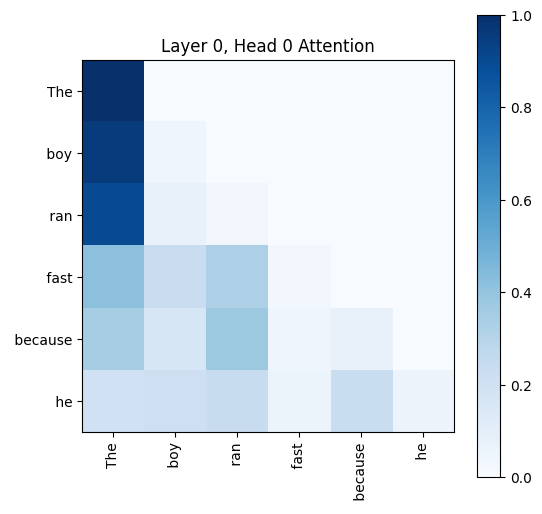

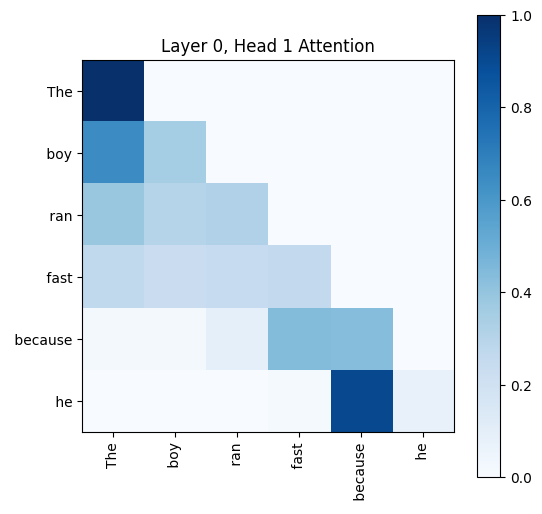

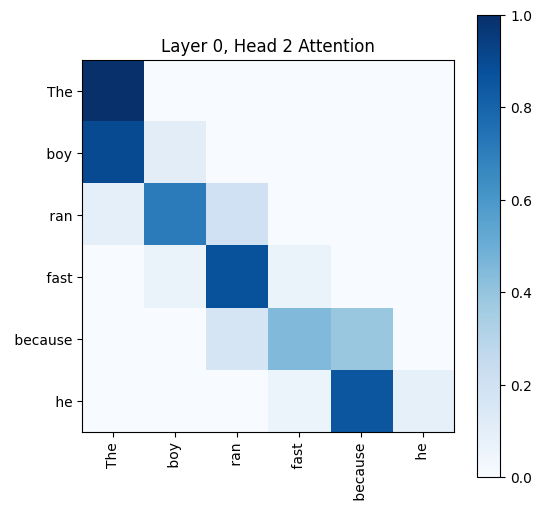

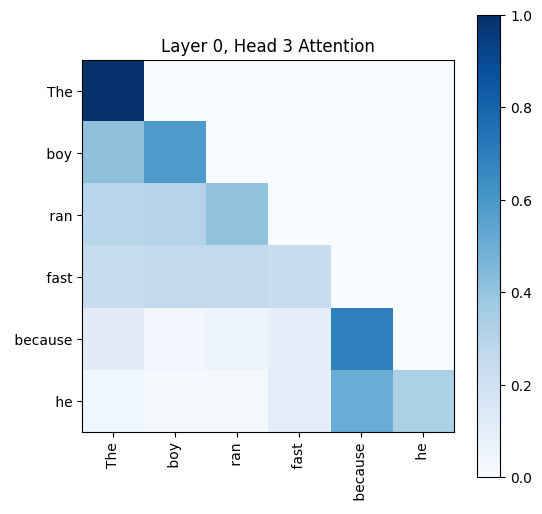

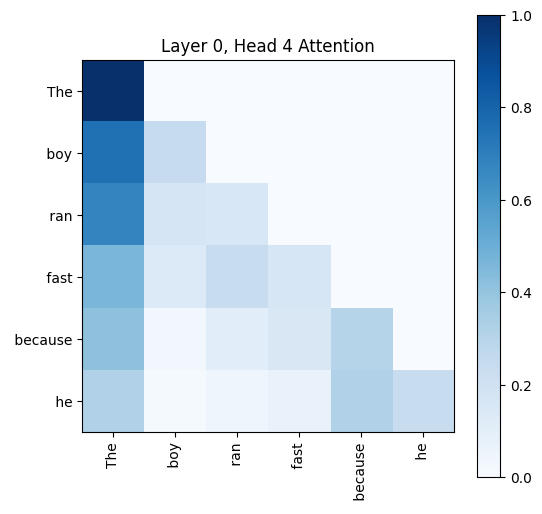

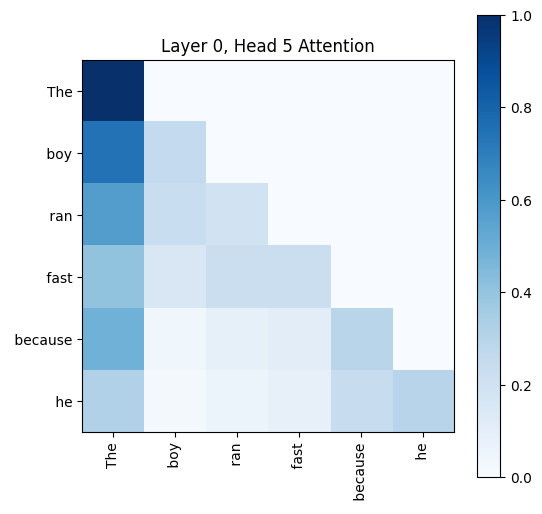

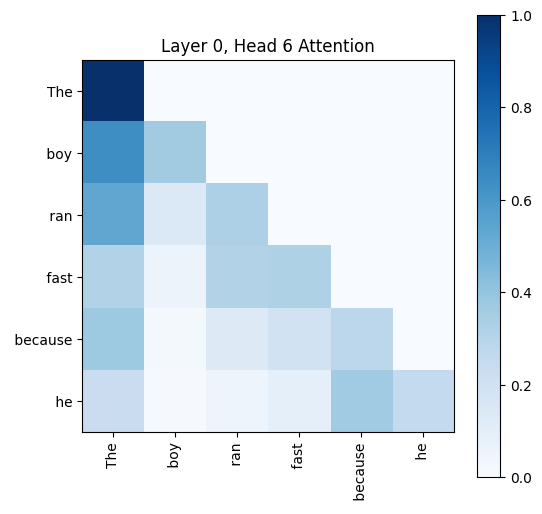

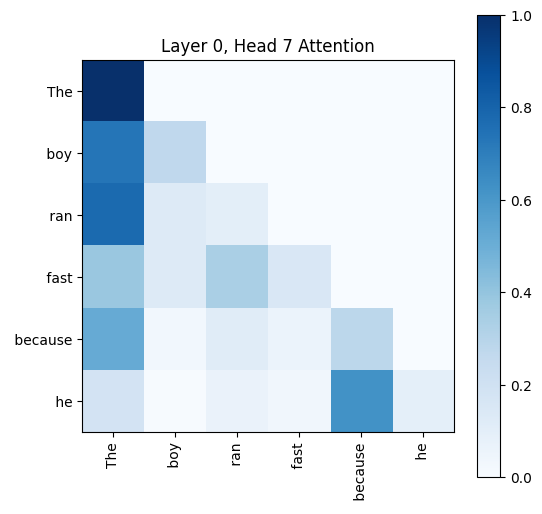

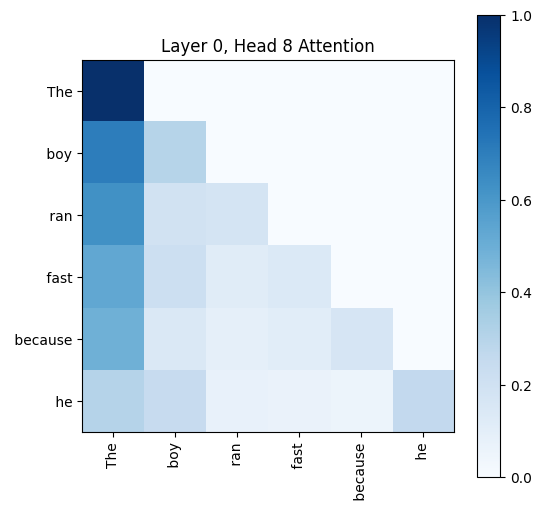

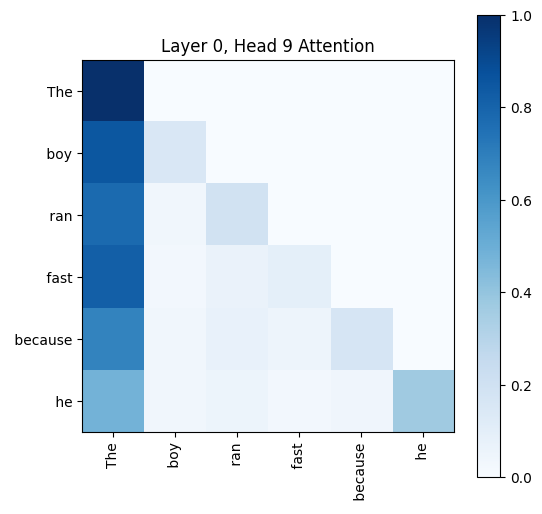

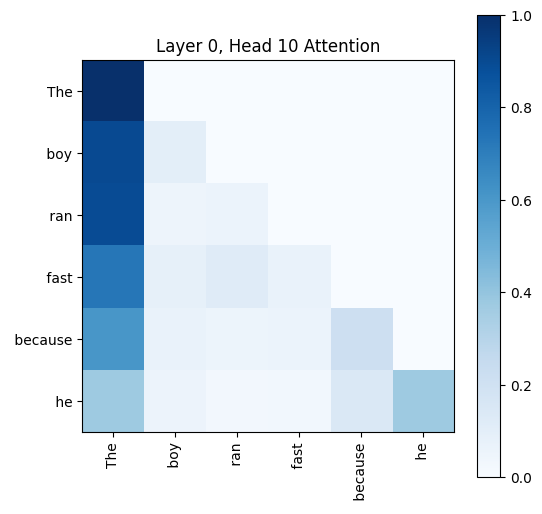

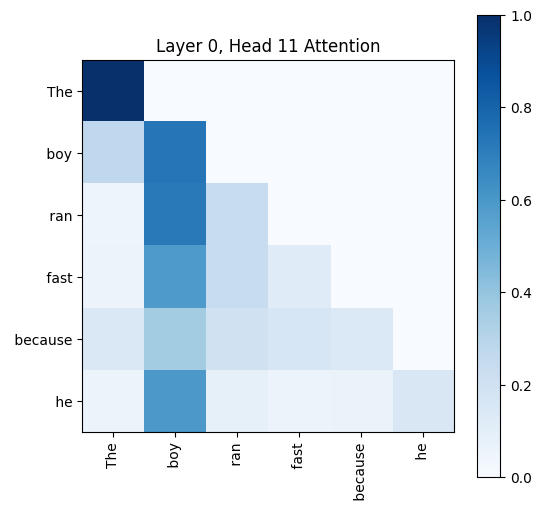

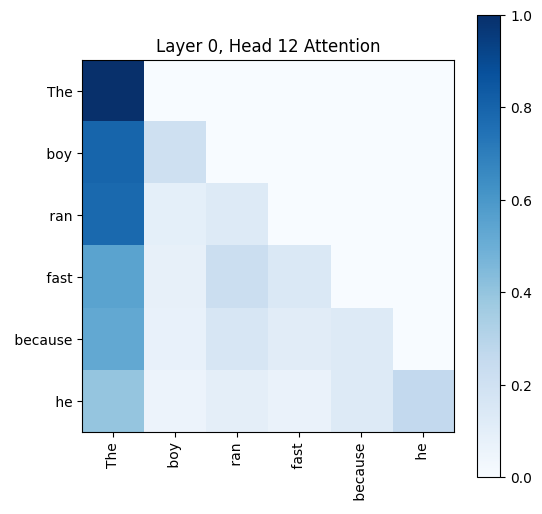

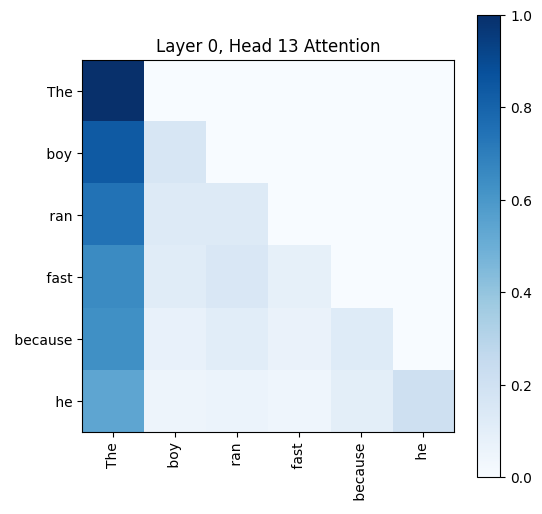

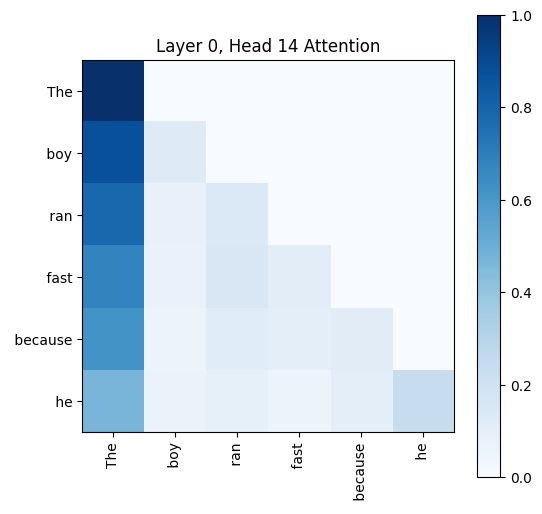

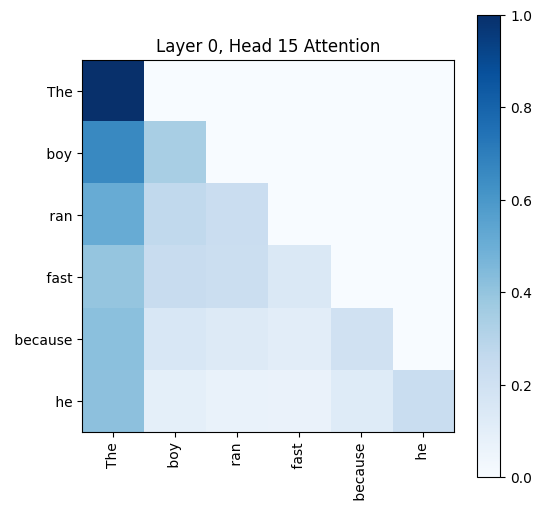

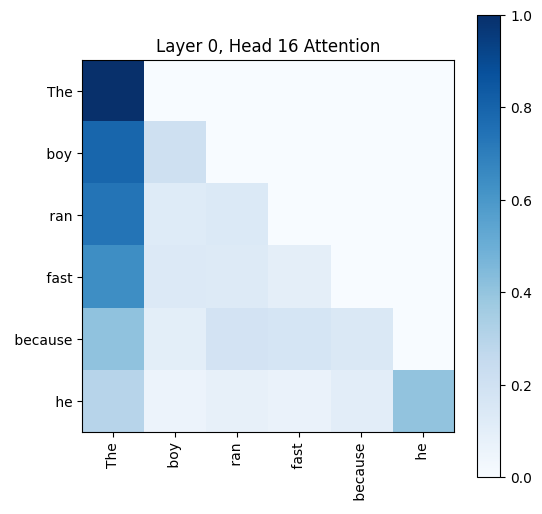

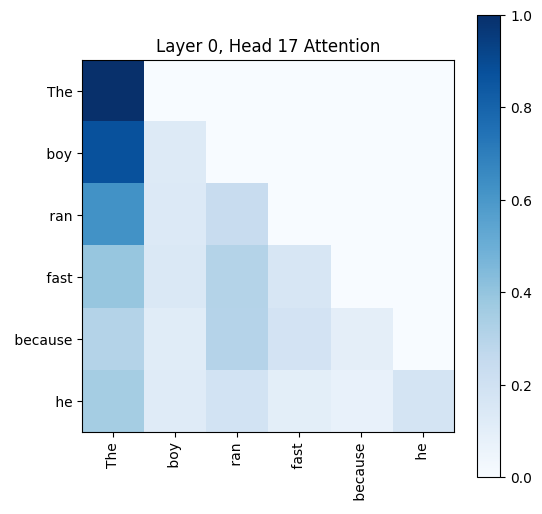

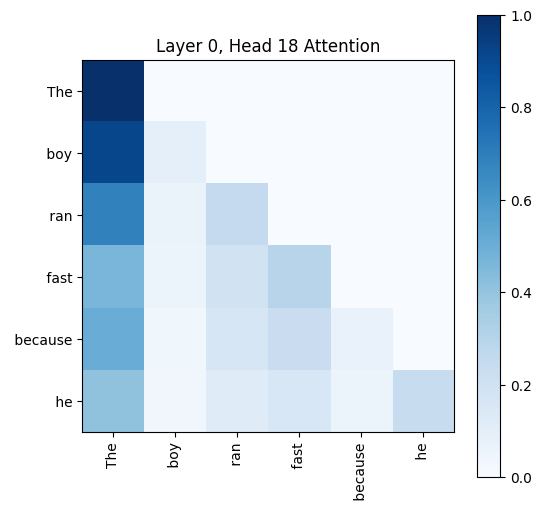

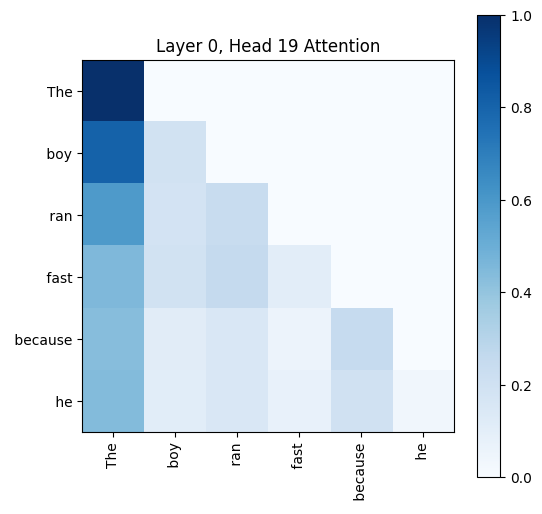

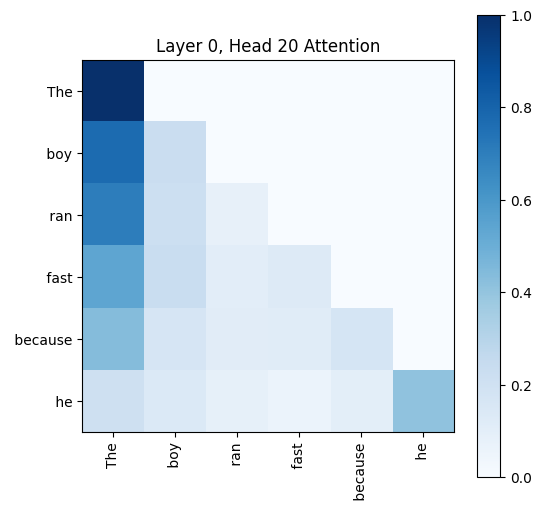

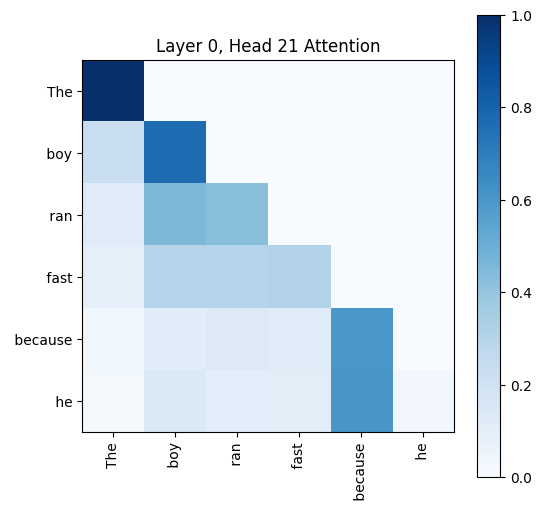

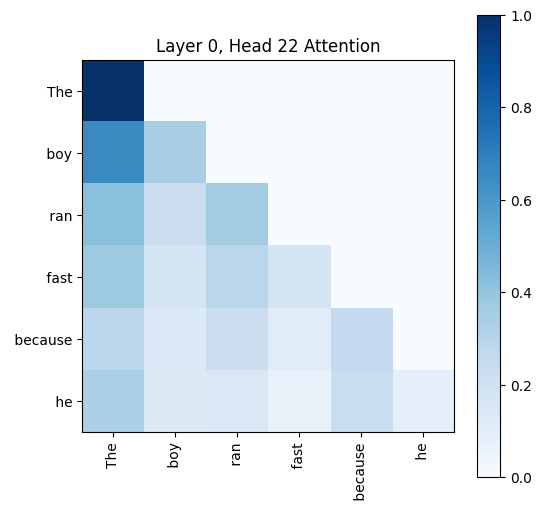

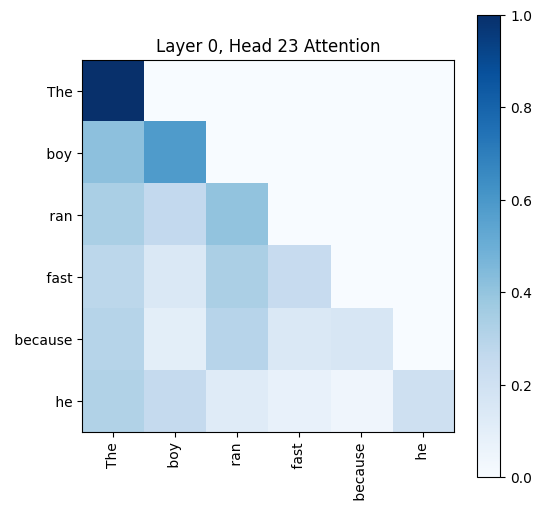

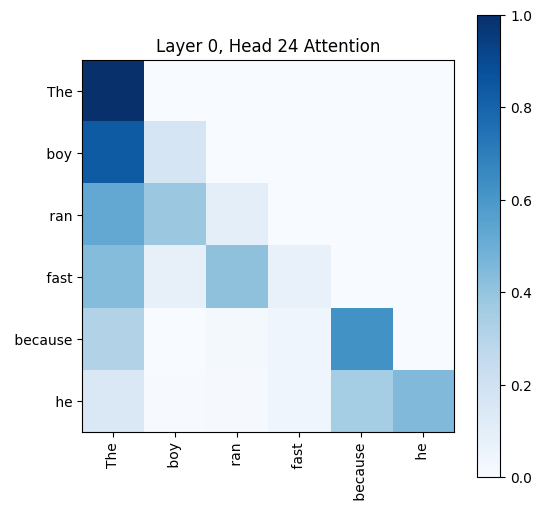

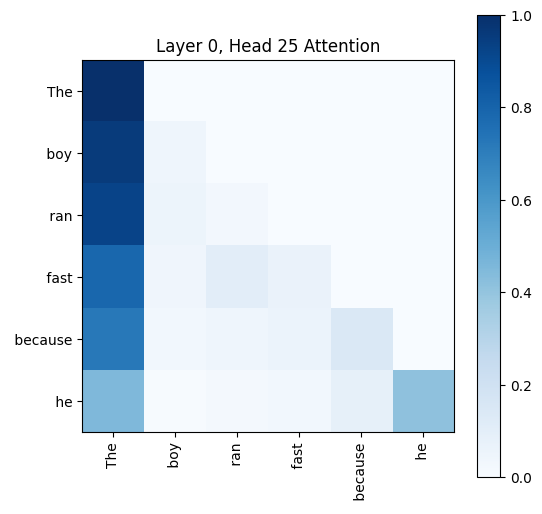

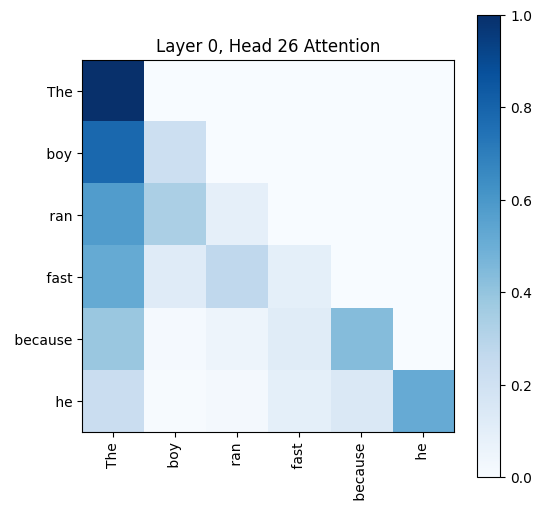

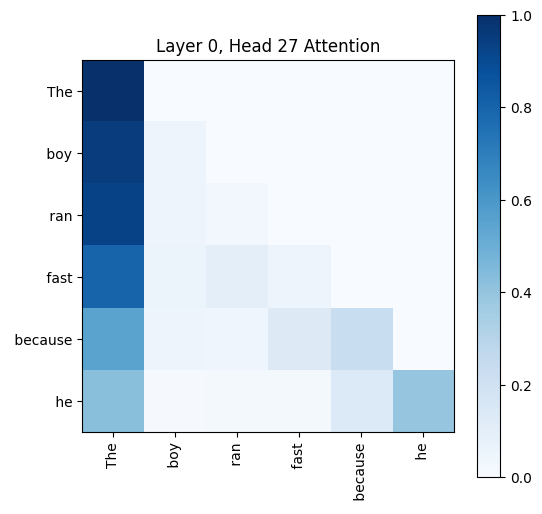

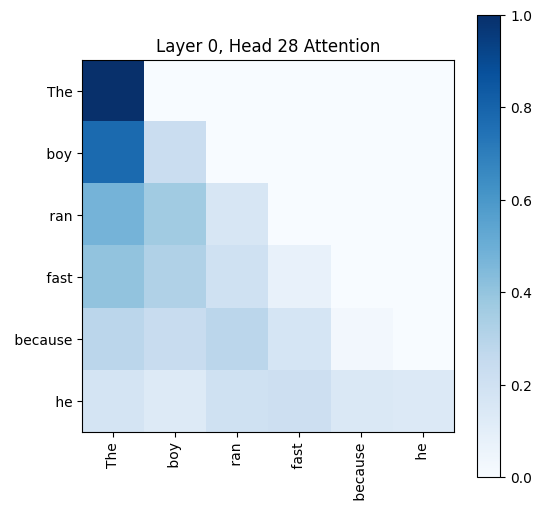

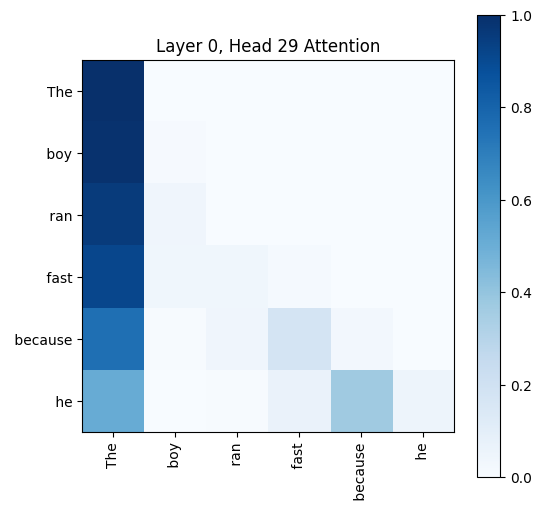

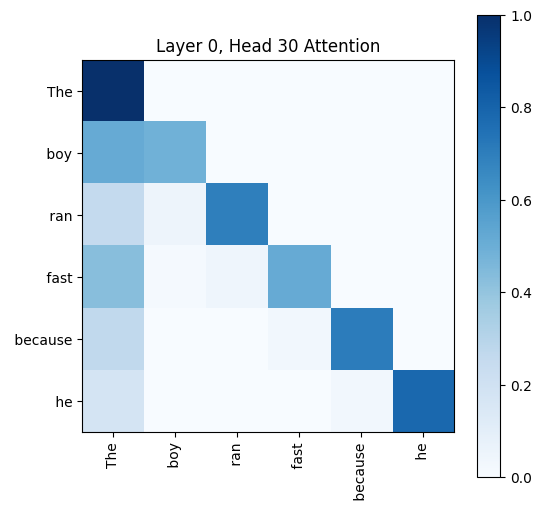

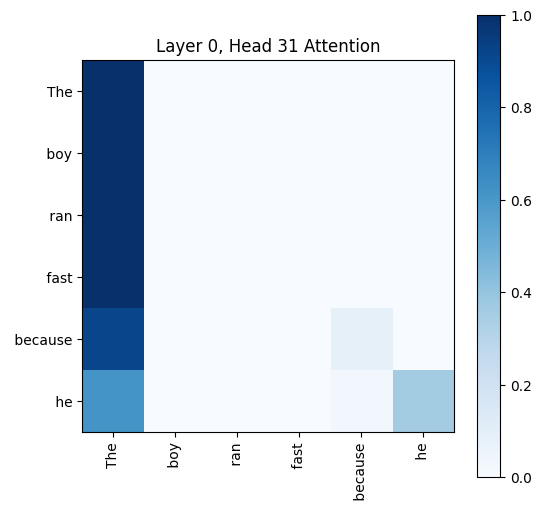

In [9]:
for head in range(32):
    layer = 0

    prompt = "The boy ran fast because he"
    input_ids = tokenizer.encode(prompt)
    token_strings = [tokenizer.decode([t]) for t in input_ids]

    single_head_weights = extractor.weights[layer][0, head, :, :]
    weights_np = np.array(single_head_weights.tolist())

    plt.figure(figsize=(6, 6))
    plt.imshow(weights_np, cmap='Blues')
    plt.xticks(range(len(token_strings)), token_strings, rotation=90)
    plt.yticks(range(len(token_strings)), token_strings)
    plt.title(f"Layer {layer}, Head {head} Attention")
    plt.colorbar()
    plt.show()

If everything above executed perfectly without error, your instrumentation is ready for actual experiments. You have successfully mapped the internals of an LLM!